# 3.5 — Forward measure y cambio de numerario

Todo lo que hemos valuado hasta aquí usó el mismo denominador: la cuenta bancaria $B_t=e^{rt}$. Bajo la medida $\mathbb{Q}$ asociada a ella, $V_t/B_t$ es martingala y de ahí sale $V_0=\mathbb{E}^{\mathbb{Q}}[e^{-rT}V_T]$. Pero $B_t$ no tiene nada de especial: **cualquier activo con precio estrictamente positivo sirve de unidad de cuenta**, y cada elección trae su propia medida de probabilidad bajo la cual los precios relativos son martingalas. El precio no cambia — sería absurdo que el valor de un derivado dependiera de en qué unidades lo midamos — pero la *dificultad del cálculo* sí cambia, y muchísimo.

Ese es el contenido práctico del cambio de numerario: elegir el denominador que hace desaparecer lo que estorba. Si estorba el factor de descuento estocástico, se usa el bono cupón cero $P(t,T)$ y se obtiene la **medida $T$-forward**, bajo la cual el forward es martingala y el descuento sale de la esperanza como un factor determinista. Si estorba el $S_T$ que multiplica al indicador en un digital asset-or-nothing, se usa el propio stock como numerario y el $S_T$ se cancela, dejando una probabilidad — el precio sale **sin calcular ninguna integral**.

Este notebook cierra M3 con esa herramienta y monta el andamio de M6-M7: la medida forward es lo que hace tratable el pricing con tasas estocásticas (Hull-White, HJM), la medida annuity es lo que hace que un swaption se vea como un Black, y la medida terminal es la que organiza el LMM. Aquí, con tasas deterministas, todas coinciden con $\mathbb{Q}$ — precisamente por eso es el lugar seguro para ver la mecánica funcionando antes de que el aparato haga falta de verdad.

## 0. Configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from qflib.black import bs_price
from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

# Canonical parameters
S0, K, r, q, sigma, T = 100.0, 100.0, 0.05, 0.0, 0.20, 1.0

print(f"S0={S0}, K={K}, r={r}, q={q}, sigma={sigma}, T={T}")
print(f"Call europeo (qflib.black.bs_price) = {bs_price(S0, K, r, q, sigma, T, 'call'):.10f}")

S0=100.0, K=100.0, r=0.05, q=0.0, sigma=0.2, T=1.0
Call europeo (qflib.black.bs_price) = 10.4505835722


## 1. El teorema de cambio de numerario

**Definición.** Un *numerario* es el precio $N_t>0$ de un activo negociable autofinanciable (una cuenta bancaria, un bono cupón cero, una acción con dividendos reinvertidos, una anualidad). Su medida martingala asociada $\mathbb{Q}^N$ es aquella bajo la cual **todo** precio negociable dividido entre $N$ es martingala:
$$
\frac{V_t}{N_t} = \mathbb{E}^{\mathbb{Q}^N}_t\!\left[\frac{V_T}{N_T}\right] \qquad\text{para todo activo negociable } V.
$$
Con $N=B$ esto es exactamente el FTAP de 2.3; el punto ahora es que la construcción no depende de haber elegido $B$.

**Teorema (Geman-El Karoui-Rochet, 1995).** Si $M$ y $N$ son dos numerarios, sus medidas están relacionadas por
$$
\boxed{\;\frac{d\mathbb{Q}^N}{d\mathbb{Q}^M}\bigg|_{\mathcal{F}_t} \;=\; \frac{N_t/N_0}{M_t/M_0}\;}
$$

*Demostración.* Sea $\xi_T := \dfrac{N_T M_0}{N_0 M_T}$, que es positiva. Primero, define una medida de probabilidad: tomando $V=N$ en la propiedad de martingala bajo $\mathbb{Q}^M$ se obtiene $\mathbb{E}^{M}[N_T/M_T]=N_0/M_0$, es decir $\mathbb{E}^{M}[\xi_T]=1$. Segundo, reproduce los precios correctos: para cualquier negociable $V$,
$$
\mathbb{E}^{M}\!\left[\xi_T\frac{V_T}{N_T}\right]
= \mathbb{E}^{M}\!\left[\frac{N_TM_0}{N_0M_T}\cdot\frac{V_T}{N_T}\right]
= \frac{M_0}{N_0}\,\mathbb{E}^{M}\!\left[\frac{V_T}{M_T}\right]
= \frac{M_0}{N_0}\cdot\frac{V_0}{M_0}
= \frac{V_0}{N_0},
$$
donde el tercer paso es la propiedad de martingala **bajo $\mathbb{Q}^M$**, que es lo único que se supuso. Luego la medida con densidad $\xi_T$ hace de $V/N$ una martingala, o sea es $\mathbb{Q}^N$. $\blacksquare$

Lo notable es que la demostración es puramente algebraica: no aparece ningún browniano, ninguna integral de Itô, ninguna hipótesis de modelo. Es contabilidad de martingalas. Girsanov entra sólo después, cuando uno quiere saber *qué le pasa a la dinámica* del subyacente bajo la nueva medida — el cociente $\xi$ resulta ser la exponencial estocástica cuyo kernel es la diferencia de volatilidades de los dos numerarios, y el drift se desplaza en consecuencia.

**Verificación explícita en el modelo de un periodo de 2.1.** Con dos estados y dos numerarios (bono y stock) se puede ver el teorema sin ninguna maquinaria: el mismo derivado, dos denominadores, dos medidas, un precio.

In [2]:
# Modelo de un periodo de 2.1: S0=100 -> {120, 90}, bono 1 -> 1.05
S_up, S_dn, bond_growth = 120.0, 90.0, 1.05
claim = np.array([20.0, 0.0])  # payoff de un call con K=100 en los dos estados

# Medida asociada al bono (la Q de siempre)
p_bond = (bond_growth * S0 - S_dn) / (S_up - S_dn)
price_bond = (p_bond * claim[0] + (1 - p_bond) * claim[1]) / bond_growth

# Medida asociada al stock: dQ^S/dQ = (S_1/S_0)/(B_1/B_0), estado por estado
S_final = np.array([S_up, S_dn])
xi = (S_final / S0) / bond_growth
p_stock_meas = np.array([p_bond, 1 - p_bond]) * xi
price_stock = S0 * np.sum(p_stock_meas * (claim / S_final))  # V_0/N_0 = E^N[V_1/N_1], N = S

print(f"Q (numerario = bono):  p = [{p_bond:.6f}, {1-p_bond:.6f}]   -> precio = {price_bond:.10f}")
print(f"Q^S (numerario = stock): p = [{p_stock_meas[0]:.6f}, {p_stock_meas[1]:.6f}] -> precio = {price_stock:.10f}")
print(f"suma de probabilidades bajo Q^S = {p_stock_meas.sum():.10f}  (el teorema exige E^Q[xi] = 1)")
print(f"diferencia de precios = {abs(price_bond - price_stock):.2e}")
assert abs(p_stock_meas.sum() - 1.0) < 1e-12
assert abs(price_bond - price_stock) < 1e-12

Q (numerario = bono):  p = [0.500000, 0.500000]   -> precio = 9.5238095238
Q^S (numerario = stock): p = [0.571429, 0.428571] -> precio = 9.5238095238
suma de probabilidades bajo Q^S = 1.0000000000  (el teorema exige E^Q[xi] = 1)
diferencia de precios = 0.00e+00


## 2. La medida $T$-forward y Black-76

Tomemos como numerario el **bono cupón cero** $P(t,T)$, el activo que paga exactamente $1$ en $T$. La medida asociada $\mathbb{Q}^T$ se llama *medida $T$-forward*, y su gracia es que $P(T,T)=1$, así que la fórmula general se simplifica:
$$
\frac{V_0}{P(0,T)} = \mathbb{E}^{T}\!\left[\frac{V_T}{P(T,T)}\right] = \mathbb{E}^{T}[V_T]
\qquad\Longrightarrow\qquad
\boxed{\;V_0 = P(0,T)\,\mathbb{E}^{T}[V_T]\;}
$$
Compárese con $V_0=\mathbb{E}^{\mathbb{Q}}[e^{-\int_0^Tr_sds}V_T]$: bajo $\mathbb{Q}$ el descuento es una variable aleatoria **dentro** de la esperanza, correlacionada con el payoff; bajo $\mathbb{Q}^T$ sale afuera como un número, el precio de mercado del bono. Con tasas deterministas la diferencia es cosmética (es lo que comprobamos en la Demo 1); con tasas estocásticas es la diferencia entre un problema tratable y uno que no lo es, y es la razón de que M6-M7 vivan enteramente en esta medida.

**El forward es martingala bajo $\mathbb{Q}^T$.** El precio forward de un activo que paga dividendo continuo $q$ es $F_t = S_te^{-q(T-t)}/P(t,T)$. El numerador es el valor de una posición negociable (comprar $e^{-q(T-t)}$ unidades del activo y reinvertir dividendos entrega exactamente una unidad en $T$), así que $F_t$ es *precio negociable dividido entre el numerario* y por definición de $\mathbb{Q}^T$:
$$
F_t = \mathbb{E}^{T}_t[F_T] = \mathbb{E}^{T}_t[S_T],
$$
usando $F_T=S_T$. Es decir: **el forward de hoy es la esperanza del spot futuro, pero bajo $\mathbb{Q}^T$, no bajo la medida física ni bajo $\mathbb{Q}$.**

**Black-76.** Si además se postula que $F$ es lognormal bajo $\mathbb{Q}^T$ con volatilidad $\sigma$ — es decir $dF_t=\sigma F_tdW_t^T$, sin drift porque ya sabemos que es martingala — entonces $F_T=F_0e^{-\frac12\sigma^2T+\sigma W_T^T}$ y la esperanza del payoff es la misma integral gaussiana de 3.1:
$$
\boxed{\;\text{Call}_0 = P(0,T)\big[F_0N(d_1)-KN(d_2)\big],\qquad d_{1,2}=\frac{\ln(F_0/K)\pm\frac12\sigma^2T}{\sigma\sqrt{T}}\;}
$$
Ésta es la fórmula que cotiza el mercado de caps, swaptions y opciones sobre futuros — con $F_0$ el forward observable y $P(0,T)$ el descuento observable, sin necesidad de modelar $S$ ni $r$ por separado. Con tasas deterministas, $F_0=S_0e^{(r-q)T}$ y $P(0,T)=e^{-rT}$ la reducen algebraicamente a Black-Scholes, lo que verificamos abajo a $10^{-10}$.

In [3]:
def black76_call(F0, K, discount, sigma, T):
    '''Black-76 call on a forward (Section 2). Price quoted off the forward and the discount factor.'''
    std = sigma * np.sqrt(T)
    d1 = (np.log(F0 / K) + 0.5 * std**2) / std
    d2 = d1 - std
    return discount * (F0 * norm.cdf(d1) - K * norm.cdf(d2))


F0 = S0 * np.exp((r - q) * T)   # forward con tasas deterministas
P0T = np.exp(-r * T)            # bono cupon cero = numerario de Q^T
bs_call = bs_price(S0, K, r, q, sigma, T, "call")
b76_call = black76_call(F0, K, P0T, sigma, T)

print(f"F(0,T) = {F0:.10f}   |   P(0,T) = {P0T:.10f}")
print(f"Black-76      = {b76_call:.12f}")
print(f"Black-Scholes = {bs_call:.12f}")
print(f"diferencia    = {abs(b76_call - bs_call):.2e}")

F(0,T) = 105.1271096376   |   P(0,T) = 0.9512294245
Black-76      = 10.450583572186
Black-Scholes = 10.450583572186
diferencia    = 1.42e-14


## 3. Demo 1 — con tasas deterministas, $\mathbb{Q}$ y $\mathbb{Q}^T$ son la misma medida

Sanity check antes de usar la herramienta en serio. Con $r$ determinista el numerario $P(t,T)=e^{-r(T-t)}$ es determinista, así que la densidad del teorema de la §1 vale
$$
\frac{d\mathbb{Q}^T}{d\mathbb{Q}}\bigg|_{\mathcal{F}_T} = \frac{P(T,T)/P(0,T)}{B_T/B_0} = \frac{e^{rT}}{e^{rT}} = 1,
$$
es decir $\mathbb{Q}^T=\mathbb{Q}$ **exactamente**, no aproximadamente. Simulamos las dos valuaciones con **los mismos** normales $Z$: bajo $\mathbb{Q}$ el spot con drift $r-q$, y bajo $\mathbb{Q}^T$ el forward *sin drift* (es martingala). Los dos estimadores no deben diferir dentro del error muestral — deben coincidir **trayectoria por trayectoria**, hasta precisión de máquina, porque $F_T=S_T$ para cada $Z$.

Es un resultado deliberadamente aburrido: es el control de que la mecánica está bien montada. Lo interesante empieza en M6, cuando $P(t,T)$ sea estocástico y las dos medidas dejen de coincidir — ahí aparecen los ajustes de convexidad, que son exactamente la medida de ese desacuerdo.

In [4]:
n_paths = 400_000
Z = rng.standard_normal(n_paths)

# Bajo Q: se simula el spot con drift r-q y se descuenta con B_T
S_T = S0 * np.exp((r - q - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
payoff_Q = np.exp(-r * T) * np.maximum(S_T - K, 0.0)
mc_Q, se_Q = payoff_Q.mean(), payoff_Q.std(ddof=1) / np.sqrt(n_paths)

# Bajo Q^T: se simula el forward SIN drift (martingala) y se descuenta con P(0,T)
F_T = F0 * np.exp(-0.5 * sigma**2 * T + sigma * np.sqrt(T) * Z)
payoff_QT = P0T * np.maximum(F_T - K, 0.0)
mc_QT, se_QT = payoff_QT.mean(), payoff_QT.std(ddof=1) / np.sqrt(n_paths)

print(f"Analitico (Black-Scholes)     = {bs_call:.10f}")
print(f"MC bajo Q                     = {mc_Q:.10f} +- {3*se_Q:.6f} (3 SE)  [z = {abs(mc_Q-bs_call)/se_Q:.3f}]")
print(f"MC bajo Q^T (forward driftless) = {mc_QT:.10f} +- {3*se_QT:.6f} (3 SE)  [z = {abs(mc_QT-bs_call)/se_QT:.3f}]")
print(f"|MC_Q - MC_QT| = {abs(mc_Q - mc_QT):.2e}   <- coinciden trayectoria a trayectoria, no solo en media")
print(f"max_i |F_T - S_T| = {np.abs(F_T - S_T).max():.2e}   (F_T = S_T por definicion del forward en T)")

Analitico (Black-Scholes)     = 10.4505835722
MC bajo Q                     = 10.4540330607 +- 0.069999 (3 SE)  [z = 0.148]
MC bajo Q^T (forward driftless) = 10.4540330607 +- 0.069999 (3 SE)  [z = 0.148]
|MC_Q - MC_QT| = 7.11e-15   <- coinciden trayectoria a trayectoria, no solo en media
max_i |F_T - S_T| = 5.68e-14   (F_T = S_T por definicion del forward en T)


## 4. El stock como numerario: el digital asset-or-nothing sin integrales

Ahora el caso donde el cambio de numerario no es cosmético sino que ahorra trabajo de verdad. Recordemos de 3.3 el digital *asset-or-nothing*, que paga $S_T$ si termina in-the-money:
$$
V_0 = \mathbb{E}^{\mathbb{Q}}\big[e^{-rT}S_T\mathbf{1}_{\{S_T>K\}}\big].
$$
Calculado a la fuerza bruta, esto es una integral gaussiana con un $e^{\sigma\sqrt{T}z}$ multiplicando al indicador, que hay que completar el cuadrado para resolver. Con el numerario correcto no hay integral que resolver.

Tomemos $N_t = S_te^{qt}$: el stock con dividendos reinvertidos, que es negociable y positivo. Por la §1, $V_0/N_0 = \mathbb{E}^{S}[V_T/N_T]$, y como el payoff es $V_T=S_T\mathbf{1}$,
$$
V_0 = S_0\,\mathbb{E}^{S}\!\left[\frac{S_T\mathbf{1}_{\{S_T>K\}}}{S_Te^{qT}}\right] = S_0e^{-qT}\,\mathbb{E}^{S}\big[\mathbf{1}_{\{S_T>K\}}\big] = S_0e^{-qT}\,\mathbb{Q}^{S}(S_T>K).
$$
**El $S_T$ se canceló contra el numerario** y quedó una probabilidad. Falta saber bajo qué dinámica: la densidad del teorema es $\xi_T=(S_Te^{qT}/S_0)/e^{rT}=e^{-\frac12\sigma^2T+\sigma W_T}$, exactamente la exponencial estocástica de kernel $\sigma$, así que por Girsanov (1.5) $W_t^S=W_t-\sigma t$ es browniano bajo $\mathbb{Q}^S$ y el drift del stock se desplaza:
$$
\frac{dS_t}{S_t} = (r-q+\sigma^2)\,dt + \sigma\,dW^S_t.
$$
Con ese drift, $\ln(S_T/S_0)\sim\mathcal{N}\big((r-q+\tfrac12\sigma^2)T,\ \sigma^2T\big)$ y por lo tanto
$$
\mathbb{Q}^S(S_T>K) = N\!\left(\frac{\ln(S_0/K)+(r-q+\tfrac12\sigma^2)T}{\sigma\sqrt{T}}\right) = N(d_1)
\qquad\Longrightarrow\qquad \boxed{\;V_0 = S_0e^{-qT}N(d_1)\;}
$$
Aparece $N(d_1)$ — y ahora ya no es un símbolo que sale de completar el cuadrado, sino **una probabilidad genuina**: la probabilidad de terminar in-the-money bajo la medida del stock. (Dicho sea de paso, esto explica de dónde viene el delta $e^{-qT}N(d_1)$ del call: el call es un asset-or-nothing menos $K$ cash-or-nothings, y $N(d_2)=\mathbb{Q}(S_T>K)$ es la misma probabilidad bajo $\mathbb{Q}$.)

Abajo llegamos al mismo número por **tres caminos**: la fórmula analítica, un MC bajo $\mathbb{Q}$ (que promedia $e^{-rT}S_T\mathbf{1}$) y un MC bajo $\mathbb{Q}^S$ (que sólo cuenta cuántas trayectorias terminan ITM, con el drift desplazado). Un detalle que vale la pena notar en los resultados: el estimador bajo $\mathbb{Q}^S$ tiene **menor** error estándar, porque muestrea un indicador acotado en vez de un payoff con cola lognormal — cambiar de numerario también es una técnica de reducción de varianza, idea que M4 retoma como *importance sampling*.

Analitico  S0 e^-qT N(d1)      = 63.6830651176      [N(d1) = 0.636831]
MC bajo Q   (paga S_T 1_ITM)   = 63.6367945698 +- 0.273525 (3 SE)  [z = 0.507]
MC bajo Q^S (cuenta 1_ITM)     = 63.6780000000 +- 0.228124 (3 SE)  [z = 0.067]
Q^S(S_T > K) simulada = 0.636780  vs  N(d1) = 0.636831
Reduccion de error estandar al cambiar de numerario: SE_Q/SE_S = 1.199x


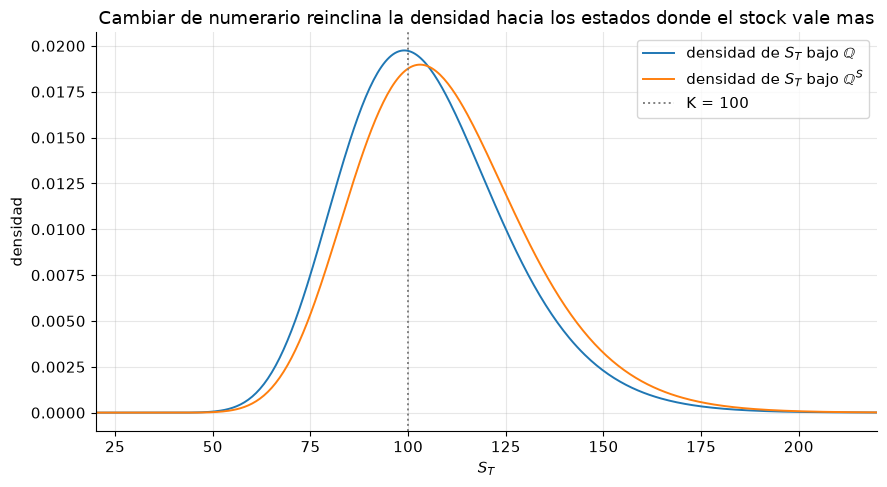

In [5]:
d1 = (np.log(S0 / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
aon_analytic = S0 * np.exp(-q * T) * norm.cdf(d1)

# Camino 2: MC bajo Q -- promediar e^{-rT} S_T 1{S_T>K} (mismos Z que la Demo 1)
aon_pay_Q = np.exp(-r * T) * np.where(S_T > K, S_T, 0.0)
aon_Q, aon_se_Q = aon_pay_Q.mean(), aon_pay_Q.std(ddof=1) / np.sqrt(n_paths)

# Camino 3: MC bajo Q^S -- drift desplazado a r-q+sigma^2, contar indicadores
S_T_stock = S0 * np.exp((r - q + 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
itm = (S_T_stock > K).astype(float)
prob_S = itm.mean()
aon_S = S0 * np.exp(-q * T) * prob_S
aon_se_S = S0 * np.exp(-q * T) * itm.std(ddof=1) / np.sqrt(n_paths)

print(f"Analitico  S0 e^-qT N(d1)      = {aon_analytic:.10f}      [N(d1) = {norm.cdf(d1):.6f}]")
print(f"MC bajo Q   (paga S_T 1_ITM)   = {aon_Q:.10f} +- {3*aon_se_Q:.6f} (3 SE)  [z = {abs(aon_Q-aon_analytic)/aon_se_Q:.3f}]")
print(f"MC bajo Q^S (cuenta 1_ITM)     = {aon_S:.10f} +- {3*aon_se_S:.6f} (3 SE)  [z = {abs(aon_S-aon_analytic)/aon_se_S:.3f}]")
print(f"Q^S(S_T > K) simulada = {prob_S:.6f}  vs  N(d1) = {norm.cdf(d1):.6f}")
print(f"Reduccion de error estandar al cambiar de numerario: SE_Q/SE_S = {aon_se_Q/aon_se_S:.3f}x")

fig, ax = plt.subplots(figsize=(9, 5))
grid = np.linspace(0.0, 300.0, 600)
lognorm_pdf = lambda x, mu: np.exp(-((np.log(x / S0) - mu) ** 2) / (2 * sigma**2 * T)) / (
    x * sigma * np.sqrt(2 * np.pi * T))
ax.plot(grid[1:], lognorm_pdf(grid[1:], (r - q - 0.5 * sigma**2) * T), label="densidad de $S_T$ bajo $\\mathbb{Q}$")
ax.plot(grid[1:], lognorm_pdf(grid[1:], (r - q + 0.5 * sigma**2) * T), label="densidad de $S_T$ bajo $\\mathbb{Q}^S$")
ax.axvline(K, color="gray", ls=":", label=f"K = {K:.0f}")
ax.set_xlim(20.0, 220.0)
ax.set_xlabel("$S_T$"); ax.set_ylabel("densidad")
ax.set_title("Cambiar de numerario reinclina la densidad hacia los estados donde el stock vale mas")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Hacia M6-M7: para qué sirve todo esto cuando las tasas no son deterministas

Con $r$ constante el capítulo entero parece un ejercicio de estilo — es que lo es, deliberadamente. El aparato se vuelve indispensable en cuanto el descuento deja de ser determinista, y así es como estructura los módulos siguientes:

- **M6 (tasa corta, Hull-White).** El precio de una opción sobre bono bajo $\mathbb{Q}$ obliga a manejar $\mathbb{E}[e^{-\int_0^Tr_sds}(P(T,S)-K)^+]$, con descuento y payoff correlacionados. Bajo $\mathbb{Q}^T$ el descuento sale como $P(0,T)$ y queda una esperanza de un payoff sobre un forward que es martingala: el precio del caplet vuelve a ser un Black. Los **ajustes de convexidad** (por ejemplo pagar una tasa LIBOR en una fecha distinta a la natural) son exactamente el drift que aparece al valuar bajo la medida "equivocada", es decir, la diferencia entre $\mathbb{Q}^{T_1}$ y $\mathbb{Q}^{T_2}$.
- **M7 (LMM y swaptions).** Cada tasa forward $L_i$ es martingala bajo *su propia* medida $\mathbb{Q}^{T_{i+1}}$, pero un LMM las necesita a todas simultáneamente bajo una sola: al pasarlas a la **medida terminal** aparecen los drifts acoplados característicos del modelo, que no son más que el teorema de la §1 aplicado en cadena. Y para swaptions se usa la **medida annuity**, con numerario $A(t)=\sum_i\tau_iP(t,T_i)$: bajo ella la tasa swap es martingala y la fórmula de Black para swaptions se cae de la misma derivación que Black-76 de la §2.
- **M8-M9 (vol estocástica, FX).** El cambio de numerario también es lo que relaciona la medida doméstica con la extranjera en FX (la simetría put-call de divisas es un cambio de numerario), y lo que permite escribir las opciones sobre forwards en modelos con vol estocástica.

Dicho de otro modo: lo único que cambia de aquí en adelante es *cuál* numerario conviene, no la mecánica. Por eso valía la pena verla funcionar en el caso donde se puede comprobar contra fórmulas exactas.

## 6. Validación

Tres asserts, todos contra referencias exactas (no hay tolerancias inventadas):

1. **Black-76 vs Black-Scholes vs QuantLib `BlackCalculator`**, `atol=1e-10`: con tasas deterministas las tres son la misma fórmula reescrita, así que sólo pueden diferir por redondeo.
2. **Los tres caminos del asset-or-nothing**: el analítico contra QuantLib `AssetOrNothingPayoff` a `atol=1e-10`, y los dos Monte Carlo dentro de 3 SE.
3. **$\mathbb{Q}$ vs $\mathbb{Q}^T$**: coincidencia trayectoria a trayectoria, `atol=1e-9` sobre el máximo de la diferencia — no un test estadístico, uno de identidad.

In [6]:
import QuantLib as ql

eval_date = ql.Date(29, 7, 2026)
ql.Settings.instance().evaluationDate = eval_date
day_count = ql.Actual365Fixed()
calendar = ql.NullCalendar()

maturity = eval_date + int(round(T * 365))
T_actual = day_count.yearFraction(eval_date, maturity)
exercise = ql.EuropeanExercise(maturity)

spot_handle = ql.QuoteHandle(ql.SimpleQuote(S0))
rate_ts = ql.YieldTermStructureHandle(ql.FlatForward(eval_date, r, day_count))
div_ts = ql.YieldTermStructureHandle(ql.FlatForward(eval_date, q, day_count))
vol_ts = ql.BlackVolTermStructureHandle(ql.BlackConstantVol(eval_date, calendar, sigma, day_count))
process = ql.BlackScholesMertonProcess(spot_handle, div_ts, rate_ts, vol_ts)

print(f"T_actual = {T_actual} (target T = {T})")

T_actual = 1.0 (target T = 1.0)


In [7]:
# --- 1. Black-76 vs Black-Scholes vs QuantLib BlackCalculator ---
ql_black = ql.BlackCalculator(ql.PlainVanillaPayoff(ql.Option.Call, K), F0, sigma * np.sqrt(T_actual), P0T).value()
print(f"Black-76 propio: {b76_call:.12f} | QuantLib BlackCalculator: {ql_black:.12f} | "
      f"Black-Scholes: {bs_call:.12f}")
np.testing.assert_allclose(b76_call, ql_black, atol=1e-10)
np.testing.assert_allclose(b76_call, bs_call, atol=1e-10)
print("Black-76 == BlackCalculator == Black-Scholes: dentro de atol=1e-10.")

Black-76 propio: 10.450583572186 | QuantLib BlackCalculator: 10.450583572186 | Black-Scholes: 10.450583572186
Black-76 == BlackCalculator == Black-Scholes: dentro de atol=1e-10.


In [8]:
# --- 2. Asset-or-nothing: analitico vs QuantLib, y los dos MC dentro de 3 SE ---
aon_opt = ql.VanillaOption(ql.AssetOrNothingPayoff(ql.Option.Call, K), exercise)
aon_opt.setPricingEngine(ql.AnalyticEuropeanEngine(process))
ql_aon = aon_opt.NPV()
print(f"Asset-or-nothing -- QuantLib: {ql_aon:.10f} | propio S0 e^-qT N(d1): {aon_analytic:.10f} | "
      f"diff: {abs(ql_aon - aon_analytic):.2e}")
np.testing.assert_allclose(aon_analytic, ql_aon, atol=1e-10)

z_aon_Q = abs(aon_Q - ql_aon) / aon_se_Q
z_aon_S = abs(aon_S - ql_aon) / aon_se_S
print(f"MC bajo Q   vs QuantLib: |diff|/SE = {z_aon_Q:.3f} (<=3? {z_aon_Q <= 3.0})")
print(f"MC bajo Q^S vs QuantLib: |diff|/SE = {z_aon_S:.3f} (<=3? {z_aon_S <= 3.0})")
assert z_aon_Q <= 3.0 and z_aon_S <= 3.0
print("Asset-or-nothing: los tres caminos coinciden.")

Asset-or-nothing -- QuantLib: 63.6830651176 | propio S0 e^-qT N(d1): 63.6830651176 | diff: 1.42e-14
MC bajo Q   vs QuantLib: |diff|/SE = 0.507 (<=3? True)
MC bajo Q^S vs QuantLib: |diff|/SE = 0.067 (<=3? True)
Asset-or-nothing: los tres caminos coinciden.


In [9]:
# --- 3. Q vs Q^T: identidad trayectoria a trayectoria (tasas deterministas) ---
max_path_diff = np.abs(payoff_Q - payoff_QT).max()
print(f"max_i |payoff bajo Q - payoff bajo Q^T| = {max_path_diff:.2e}")
np.testing.assert_allclose(payoff_Q, payoff_QT, atol=1e-9)
print("Q y Q^T: identicas trayectoria a trayectoria (atol=1e-9), como exige dQ^T/dQ = 1.")

print()
print("Validacion completa: 3/3 dentro de tolerancia.")

max_i |payoff bajo Q - payoff bajo Q^T| = 5.68e-14
Q y Q^T: identicas trayectoria a trayectoria (atol=1e-9), como exige dQ^T/dQ = 1.

Validacion completa: 3/3 dentro de tolerancia.


## Referencias

- Geman, H., El Karoui, N. & Rochet, J.-C. (1995). *Changes of Numeraire, Changes of Probability Measure and Option Pricing*. Journal of Applied Probability, 32(2), 443-458.
- Black, F. (1976). *The Pricing of Commodity Contracts*. Journal of Financial Economics, 3(1-2), 167-179.
- Jamshidian, F. (1989). *An Exact Bond Option Formula*. Journal of Finance, 44(1), 205-209. (la medida forward en acción)
- Shreve, S.E. (2004). *Stochastic Calculus for Finance II: Continuous-Time Models*, Springer, cap. 9 (change of numeraire).
- Brigo, D. & Mercurio, F. (2006). *Interest Rate Models - Theory and Practice*, 2nd ed., Springer, cap. 2 (medidas forward, annuity, terminal) y cap. 13 (ajustes de convexidad).
- Hull, J.C. *Options, Futures, and Other Derivatives*, 10th ed., cap. 28 (martingalas y medidas).